In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

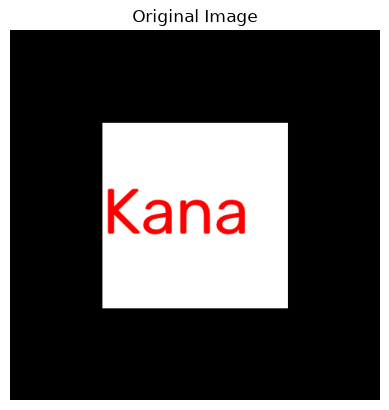

Original Image Shape: (500, 500, 3)


In [2]:
# Created the image

image = np.full((500, 500, 3), (0, 0, 0), dtype = np.uint8)

start_point = (500 // 4, 500 // 4)
end_point = (3 * 500 // 4, 3 * 500 // 4)
color = (255, 255, 255)

image = cv2.rectangle(image, start_point, end_point, color, -1)
cv2.putText(image, 'Kana', (start_point[0], start_point[1] + 150), fontFace = cv2.FONT_HERSHEY_SIMPLEX, fontScale = 3, color = (0, 0, 255), thickness = 1)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Original Image')
plt.show()
print(f'Original Image Shape: {image.shape}')

#### <i>Interpolation and Transformation</i>


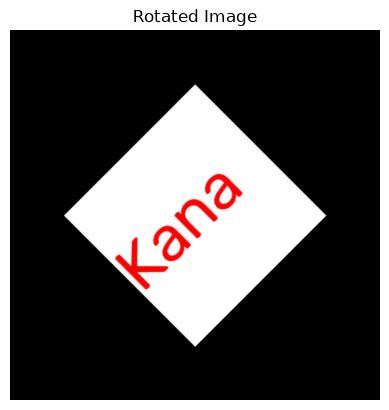

In [3]:
# Rotation

height, width, _ = image.shape
center = (height // 2, width // 2)

angle = 45
scale = 1.0
m_rotate = cv2.getRotationMatrix2D(center, angle, scale)
rotated = cv2.warpAffine(image, m_rotate, (width, height))

plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Rotated Image')
plt.show()

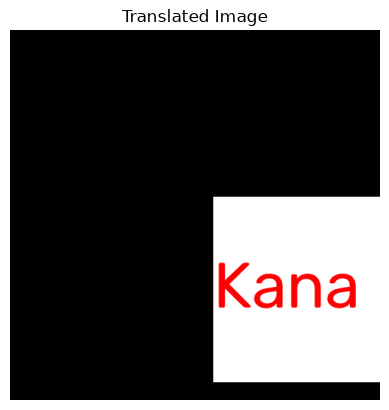

In [4]:
# Translation

tx, ty = 150, 100
m_translate = np.float32([[1, 0, tx], [0, 1, ty]])

translated = cv2.warpAffine(image, m_translate, (width, height))

plt.imshow(cv2.cvtColor(translated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Translated Image')
plt.show()


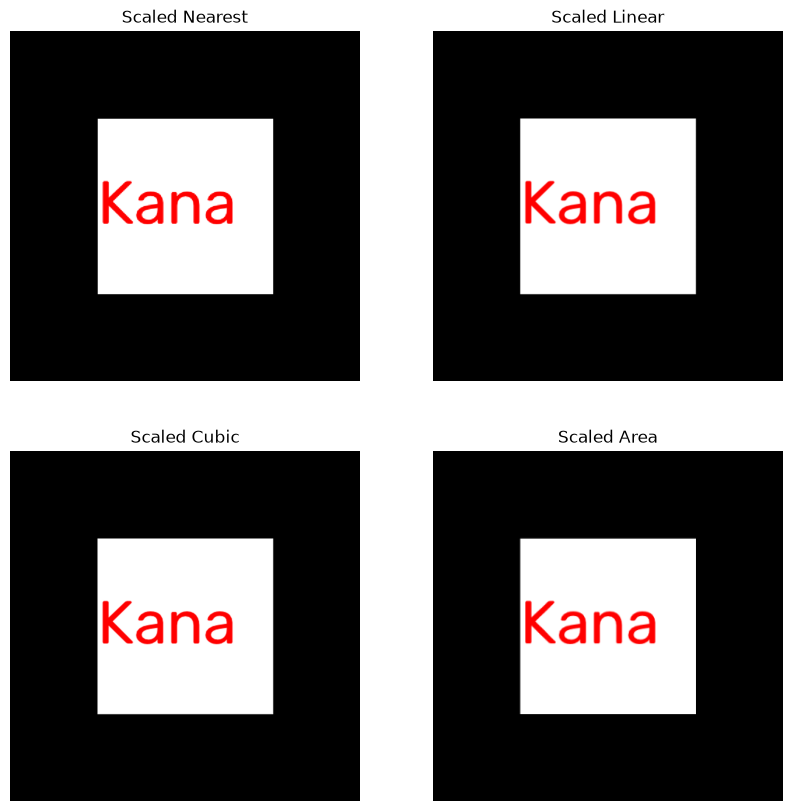

In [5]:
# Scaling

scale_factor = 1.5
new_width = int(width * scale_factor)
new_height = int(height * scale_factor)

# Fastest, but can look blocky.
scaled_nearest = cv2.resize(image, (new_width, new_height), interpolation = cv2.INTER_NEAREST)

# Good for upscaling
scaled_linear = cv2.resize(image, (new_width, new_height), interpolation = cv2.INTER_LINEAR)

# Slower but produces smoother results, good for upscaling.
scaled_cubic = cv2.resize(image, (new_width, new_height), interpolation = cv2.INTER_CUBIC)

# Preferred for downsampling(shrinking) as it avoids moire patterns.
scaled_area = cv2.resize(image, (int(new_width * 0.5), int(new_height * 0.5)), interpolation = cv2.INTER_AREA)

plt.figure(figsize = (10, 10))

plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(scaled_nearest, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Scaled Nearest')

plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(scaled_linear, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Scaled Linear')

plt.subplot(2, 2, 3)
plt.imshow(cv2.cvtColor(scaled_cubic, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Scaled Cubic')

plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(scaled_area, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Scaled Area')
plt.show()


#### <i>Convolutions and Filtering</i>

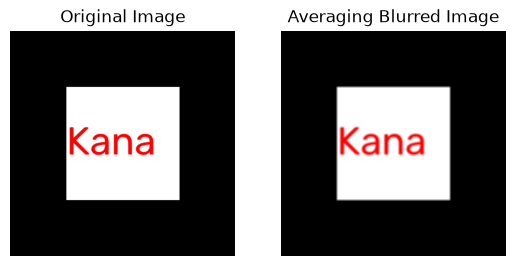

In [8]:
# Low Pass Filtering (Averaging Blur)

averaging_blurred = cv2.blur(image, (5, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(averaging_blurred, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Averaging Blurred Image')
plt.show()

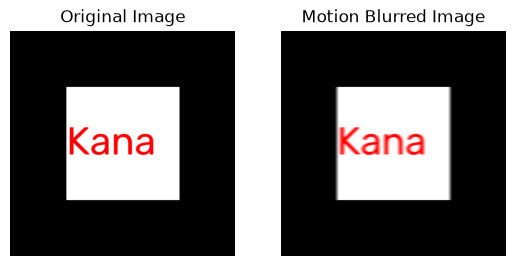

In [10]:
# Low Pass Filtering (Motion Blur)

kernel = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0]
], dtype=np.float32)

kernel = kernel / 9

motion_blurred = cv2.filter2D(image, -1, kernel)

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(motion_blurred, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Motion Blurred Image')
plt.show()

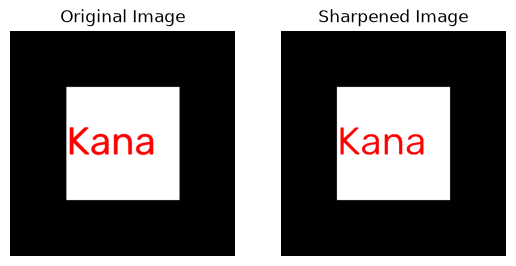

In [14]:
# Image Sharpening

sharpening_kernel = np.array([[-1, -1, -1],
                              [-1, 100, -1],
                              [-1, -1, -1]])

sharpened = cv2.filter2D(image, -1, sharpening_kernel)


plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Sharpened Image')
plt.show()